### 1D Polynomial Reproduction for SIAC

* Checks that the SIAC code correctly reproduces polynomials in 1D
* For this, the modal DG basis is created using an exact $L^2$-projection

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("../..")

In [2]:
from src.mesh import build_uniform_mesh_1d
from src.grid import local_cell_center_nodes_1d, build_grid_from_local_nodes_1d
from src.siac_modal import apply_siac_to_modal_dg_1d, trim_valid_siac_region_1d
from src.projection_approach import l2_project_exact_func_to_dg_1d
from src.evaluation import eval_dg_on_local_nodes_1d


In [3]:
# -----------------------------
# 0. Problem / domain setup
# -----------------------------
xmin, xmax = -1, 1
xlim = (xmin, xmax)

poly_deg = 5

# --------------------------------------------------
# 1. Exact polynomial test function
# --------------------------------------------------
def exact_poly1d_scaled(x):
    x = np.asarray(x)

    xhat = 2.0 * (x - xlim[0]) / (xlim[1] - xlim[0]) - 1.0
    
    u = 0.1 
    if poly_deg >= 1:
        u += 0.15*xhat 
    if poly_deg >= 2:
        u -= 0.3*xhat**2 
    if poly_deg >= 3:
        u += 0.15*xhat**3 
    if poly_deg >= 4:
        u -= 0.5*xhat**4
    if poly_deg >= 5:
        u += 0.18*xhat**5 
    return u


# DG polynomial degree  (SIAC should reproduce p = (poly_deg - 1) / 2 exactly)
p = int(np.ceil((poly_deg-1) / 2))

# DG mesh resolution
K = 24

# SIAC parameters
moments = 2 * p
BSorder = p + 1

# -----------------------------
# 2. Build DG mesh
# -----------------------------
mesh = build_uniform_mesh_1d(K=K, p=p, domain=xlim)

# -----------------------------
# 3. Exact L2 projection of polynomial onto modal DG
# -----------------------------
dg = l2_project_exact_func_to_dg_1d(
    func=exact_poly1d_scaled, 
    mesh=mesh,
    poly_max_deg=poly_deg, 
    quad_order=int(np.ceil(poly_deg + p + 1) / 2), 
    add_noise=False
)

# -----------------------------
# 4. Fine local nodes per element
# -----------------------------
n_eval = 50 * int(np.ceil(poly_deg + p + 1) / 2)
nodes_fine = local_cell_center_nodes_1d(n_eval)

# -----------------------------
# 5. Build global fine grid
# -----------------------------
grid_fine = build_grid_from_local_nodes_1d(
    mesh=dg["mesh"], 
    eval_nodes=nodes_fine
)

# -----------------------------
# 6. Evaluate exact, DG, SIAC
# -----------------------------
U_exact = exact_poly1d_scaled(
    x=grid_fine
)

U_dg = eval_dg_on_local_nodes_1d(
    dg,
    eval_nodes=nodes_fine
)

U_siac = apply_siac_to_modal_dg_1d(
    dg,
    moments=moments,
    BSorder=BSorder,
    eval_nodes=nodes_fine
)

# -----------------------------
# 7. Trim interior for SIAC comparison
# -----------------------------
n_eval = len(nodes_fine)

exact_trim, trim = trim_valid_siac_region_1d(
    U_exact,
    n_eval=n_eval,
    moments=moments,
    BSorder=BSorder, 
    return_trim=True
)

dg_trim = trim_valid_siac_region_1d(
    U_dg,
    n_eval=n_eval,
    moments=moments,
    BSorder=BSorder
)

siac_trim = trim_valid_siac_region_1d(
    U_siac,
    n_eval=n_eval,
    moments=moments,
    BSorder=BSorder
)

# -----------------------------
# 8. Errors
# -----------------------------
err_dg = dg_trim - exact_trim
err_siac = siac_trim - exact_trim

print(f"Exact Polynomial degree:    {poly_deg}")
print(f"DG degree:                  p = {p}")
print(f"SIAC parameters:            r = {moments}, n = {BSorder}")

print("trim =", trim)

print("DG max err   :", np.max(np.abs(err_dg)))
print("DG rel err   :", np.linalg.norm(err_dg) / np.linalg.norm(exact_trim))

print("SIAC max err :", np.max(np.abs(err_siac)))
print("SIAC rel err :", np.linalg.norm(err_siac) / np.linalg.norm(exact_trim))


Exact Polynomial degree:    5
DG degree:                  p = 2
SIAC parameters:            r = 4, n = 3
trim = 800
DG max err   : 5.9748281458882335e-05
DG rel err   : 9.065815270468196e-05
SIAC max err : 2.7755575615628914e-16
SIAC rel err : 4.220813093705777e-16


**Note**

For a polynomial of degree $p$
* DG should give machine precision if the DG degree is $p$ or higher
* SIAC should machine precision if the DG degree is $\left\lceil\tfrac{p-1}{2}\right\rceil$

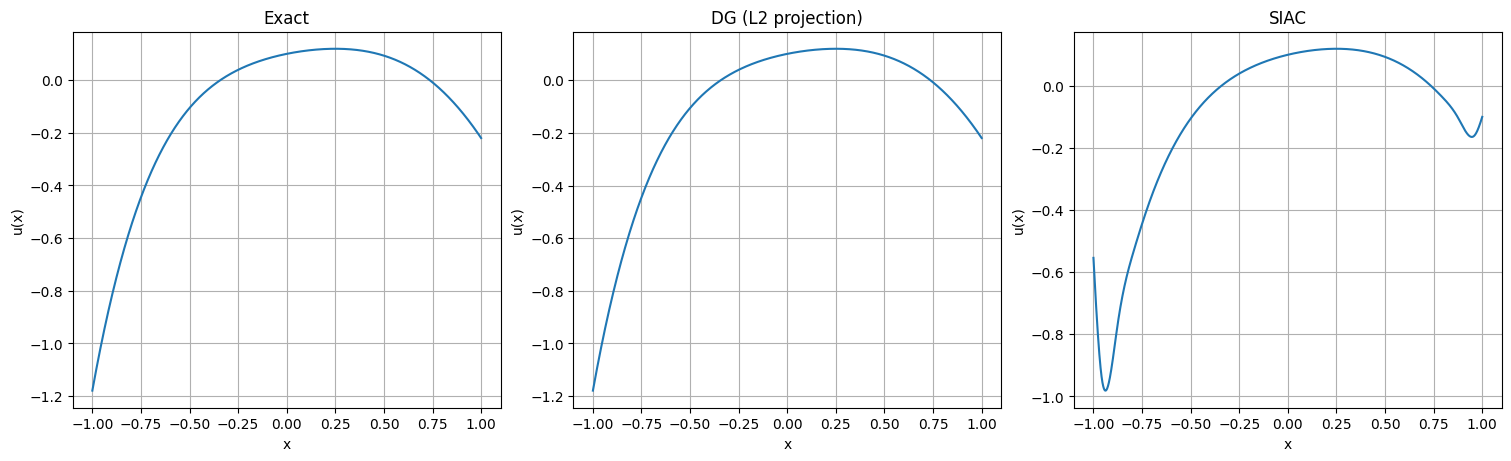

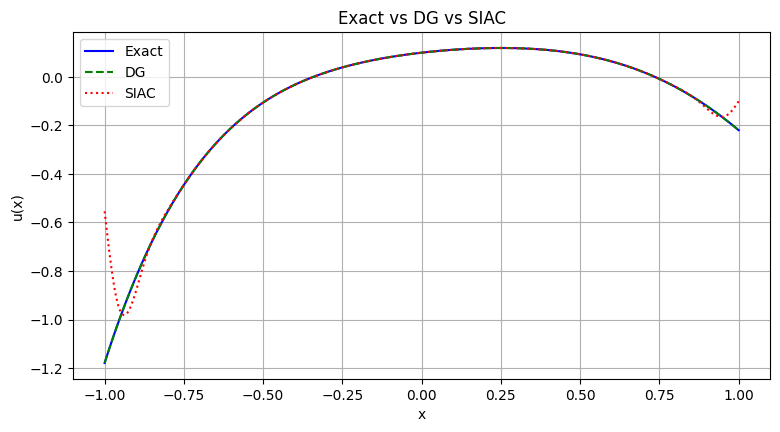

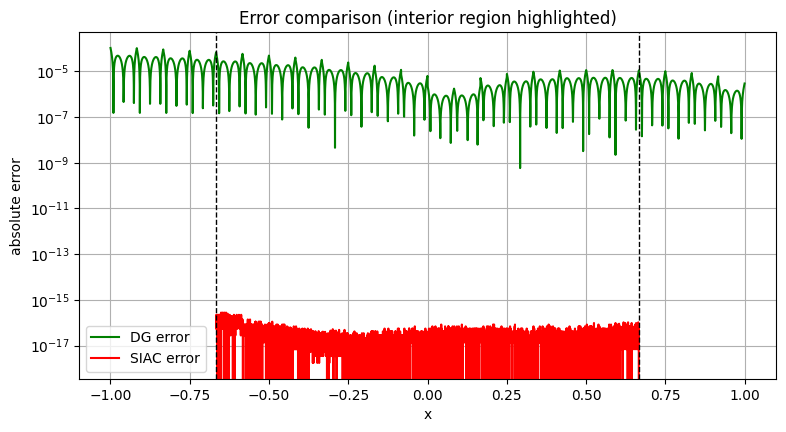

In [4]:
# --------------------------------------------------
# 7. Plots: exact, DG, SIAC
# --------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)

axes[0].plot(grid_fine, U_exact)
axes[0].set_title("Exact")
axes[0].set_xlabel("x")
axes[0].set_ylabel("u(x)")
axes[0].grid(True)

axes[1].plot(grid_fine, U_dg)
axes[1].set_title("DG (L2 projection)")
axes[1].set_xlabel("x")
axes[1].set_ylabel("u(x)")
axes[1].grid(True)

axes[2].plot(grid_fine, U_siac)
axes[2].set_title("SIAC")
axes[2].set_xlabel("x")
axes[2].set_ylabel("u(x)")
axes[2].grid(True)

plt.show()

# --------------------------------------------------
# 8. Overlay comparison
# --------------------------------------------------
plt.figure(figsize=(9, 4.5))
plt.plot(grid_fine, U_exact, "-", color="b", label="Exact")
plt.plot(grid_fine, U_dg, "--", color="g", label="DG")
plt.plot(grid_fine, U_siac, ":", color="r", label="SIAC")
plt.title("Exact vs DG vs SIAC")
plt.xlabel("x")
plt.ylabel("u(x)")
plt.grid(True)
plt.legend()
plt.show()

# --------------------------------------------------
# 9. Overlay error plot (full grid with NaNs)
# --------------------------------------------------
x_left = grid_fine[trim]
x_right = grid_fine[-trim-1]


siac_err_plot = np.full_like(U_exact, np.nan, dtype=float)
dg_err_plot = U_exact - U_dg

sl = slice(trim, -trim)
siac_err_plot[sl] = np.abs(err_siac)

plt.figure(figsize=(9, 4.5))

plt.semilogy(grid_fine, np.abs(dg_err_plot), color="green", label="DG error")
plt.semilogy(grid_fine, np.abs(siac_err_plot), color="red", label="SIAC error")

plt.axvline(x_left, color="black", linestyle="--", linewidth=1)
plt.axvline(x_right, color="black", linestyle="--", linewidth=1)

plt.title("Error comparison (interior region highlighted)")
plt.xlabel("x")
plt.ylabel("absolute error")
plt.grid(True)
plt.legend()

plt.show()

**Observe** the edge artifacts from the SIAC postprocessor (due to zero padding)

### Test with noise

Testing with noise of order $\mathcal{O}(h^{p+1})$, where $h$ is the element spacing, and $p$ is the DG degree

In [5]:

# -----------------------------
# 2. Build DG mesh
# -----------------------------
mesh = build_uniform_mesh_1d(K=K, p=p, domain=xlim)

# -----------------------------
# 3. Exact L2 projection of polynomial onto modal DG
# -----------------------------
dg = l2_project_exact_func_to_dg_1d(
    func=exact_poly1d_scaled, 
    mesh=mesh,
    poly_max_deg=poly_deg, 
    quad_order=int(np.ceil(poly_deg + p + 1) / 2), 
    add_noise=True
)

# -----------------------------
# 4. Fine local nodes per element
# -----------------------------
n_eval = 50 * int(np.ceil(poly_deg + p + 1) / 2)
nodes_fine = local_cell_center_nodes_1d(n_eval)

# -----------------------------
# 5. Build global fine grid
# -----------------------------
grid_fine = build_grid_from_local_nodes_1d(
    mesh=dg["mesh"], 
    eval_nodes=nodes_fine
)

# -----------------------------
# 6. Evaluate exact, DG, SIAC
# -----------------------------
U_exact = exact_poly1d_scaled(
    x=grid_fine
)

U_dg = eval_dg_on_local_nodes_1d(
    dg,
    eval_nodes=nodes_fine
)

U_siac = apply_siac_to_modal_dg_1d(
    dg,
    moments=moments,
    BSorder=BSorder,
    eval_nodes=nodes_fine
)

# -----------------------------
# 7. Trim interior for SIAC comparison
# -----------------------------
n_eval = len(nodes_fine)

exact_trim, trim = trim_valid_siac_region_1d(
    U_exact,
    n_eval=n_eval,
    moments=moments,
    BSorder=BSorder, 
    return_trim=True
)

dg_trim = trim_valid_siac_region_1d(
    U_dg,
    n_eval=n_eval,
    moments=moments,
    BSorder=BSorder
)

siac_trim = trim_valid_siac_region_1d(
    U_siac,
    n_eval=n_eval,
    moments=moments,
    BSorder=BSorder
)

# -----------------------------
# 8. Errors
# -----------------------------
err_dg = dg_trim - exact_trim
err_siac = siac_trim - exact_trim

print(f"Exact Polynomial degree:    {poly_deg}")
print(f"DG degree:                  p = {p}")
print(f"SIAC parameters:            r = {moments}, n = {BSorder}")

print("trim =", trim)

print("DG max err   :", np.max(np.abs(err_dg)))
print("DG rel err   :", np.linalg.norm(err_dg) / np.linalg.norm(exact_trim))

print("SIAC max err :", np.max(np.abs(err_siac)))
print("SIAC rel err :", np.linalg.norm(err_siac) / np.linalg.norm(exact_trim))


Exact Polynomial degree:    5
DG degree:                  p = 2
SIAC parameters:            r = 4, n = 3
trim = 800
DG max err   : 0.0019646638448885534
DG rel err   : 0.00446047597555574
SIAC max err : 0.0006907557376558543
SIAC rel err : 0.0026865745173106693


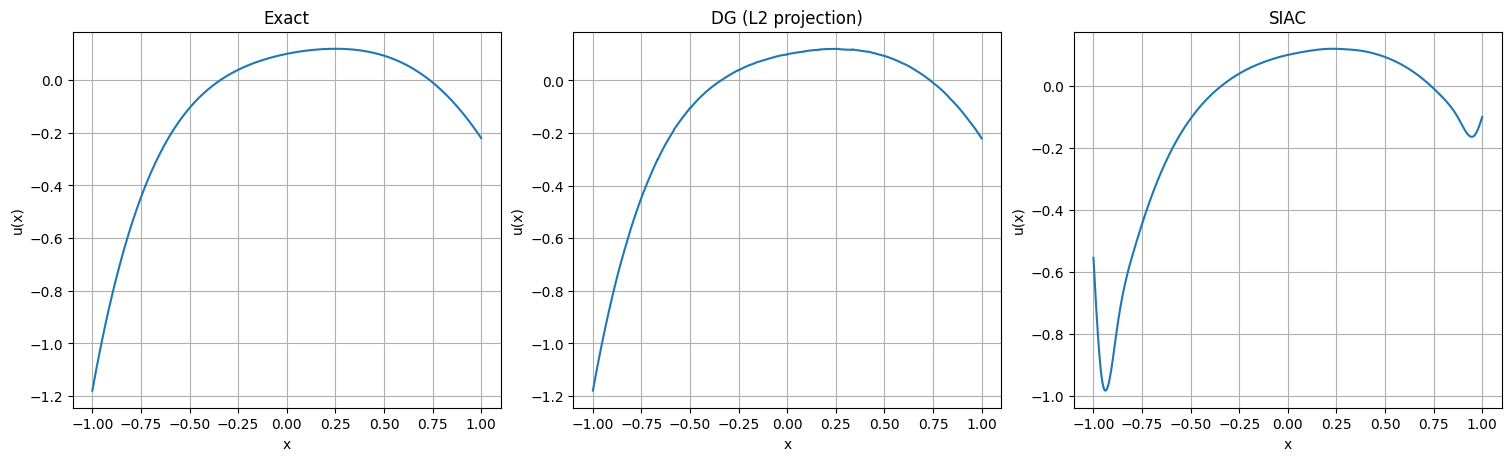

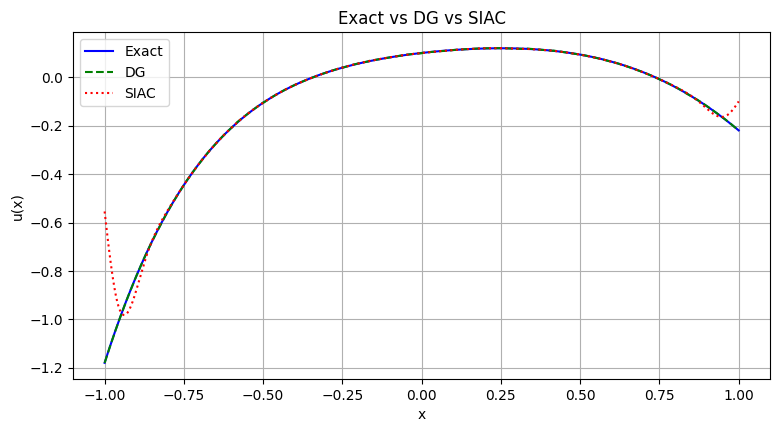

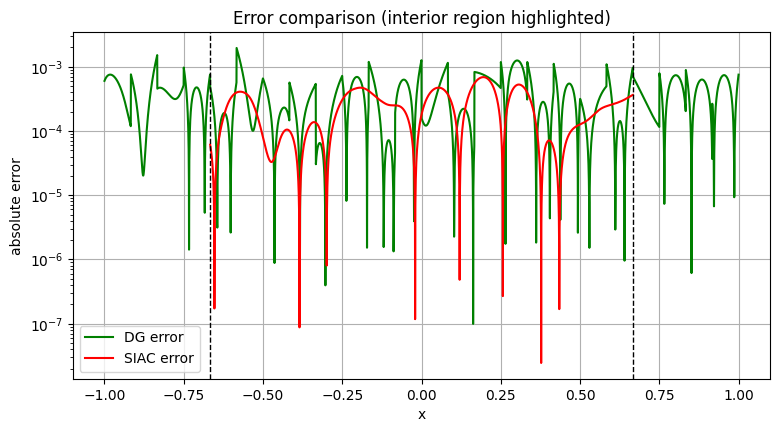

In [6]:
# --------------------------------------------------
# 7. Plots: exact, DG, SIAC
# --------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)

axes[0].plot(grid_fine, U_exact)
axes[0].set_title("Exact")
axes[0].set_xlabel("x")
axes[0].set_ylabel("u(x)")
axes[0].grid(True)

axes[1].plot(grid_fine, U_dg)
axes[1].set_title("DG (L2 projection)")
axes[1].set_xlabel("x")
axes[1].set_ylabel("u(x)")
axes[1].grid(True)

axes[2].plot(grid_fine, U_siac)
axes[2].set_title("SIAC")
axes[2].set_xlabel("x")
axes[2].set_ylabel("u(x)")
axes[2].grid(True)

plt.show()

# --------------------------------------------------
# 8. Overlay comparison
# --------------------------------------------------
plt.figure(figsize=(9, 4.5))
plt.plot(grid_fine, U_exact, "-", color="b", label="Exact")
plt.plot(grid_fine, U_dg, "--", color="g", label="DG")
plt.plot(grid_fine, U_siac, ":", color="r", label="SIAC")
plt.title("Exact vs DG vs SIAC")
plt.xlabel("x")
plt.ylabel("u(x)")
plt.grid(True)
plt.legend()
plt.show()

# --------------------------------------------------
# 9. Overlay error plot (full grid with NaNs)
# --------------------------------------------------
x_left = grid_fine[trim]
x_right = grid_fine[-trim-1]


siac_err_plot = np.full_like(U_exact, np.nan, dtype=float)
dg_err_plot = U_exact - U_dg

sl = slice(trim, -trim)
siac_err_plot[sl] = np.abs(err_siac)

plt.figure(figsize=(9, 4.5))

plt.semilogy(grid_fine, np.abs(dg_err_plot), color="green", label="DG error")
plt.semilogy(grid_fine, np.abs(siac_err_plot), color="red", label="SIAC error")

plt.axvline(x_left, color="black", linestyle="--", linewidth=1)
plt.axvline(x_right, color="black", linestyle="--", linewidth=1)

plt.title("Error comparison (interior region highlighted)")
plt.xlabel("x")
plt.ylabel("absolute error")
plt.grid(True)
plt.legend()

plt.show()